In [2]:
! pip3 install opencv-python


[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

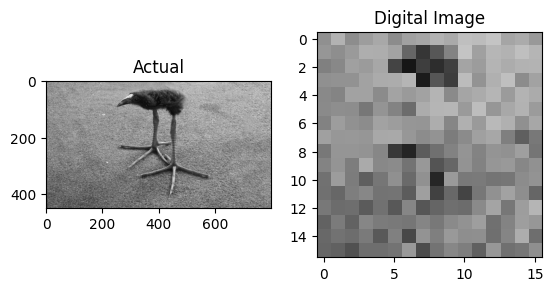

In [4]:
img_og = cv2.imread("bir.JPG")

img = cv2.cvtColor(img_og, cv2.COLOR_BGR2GRAY)
height, width = img.shape[:2]

w, h = (16, 16)
temp = cv2.resize(img, (w, h), interpolation=cv2.INTER_LINEAR)
output = cv2.resize(temp, (w, h), interpolation=cv2.INTER_NEAREST)

plt.subplot(1,2,1)
plt.title('Actual')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

plt.subplot(1,2,2)
plt.title('Digital Image')
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))

plt.show()

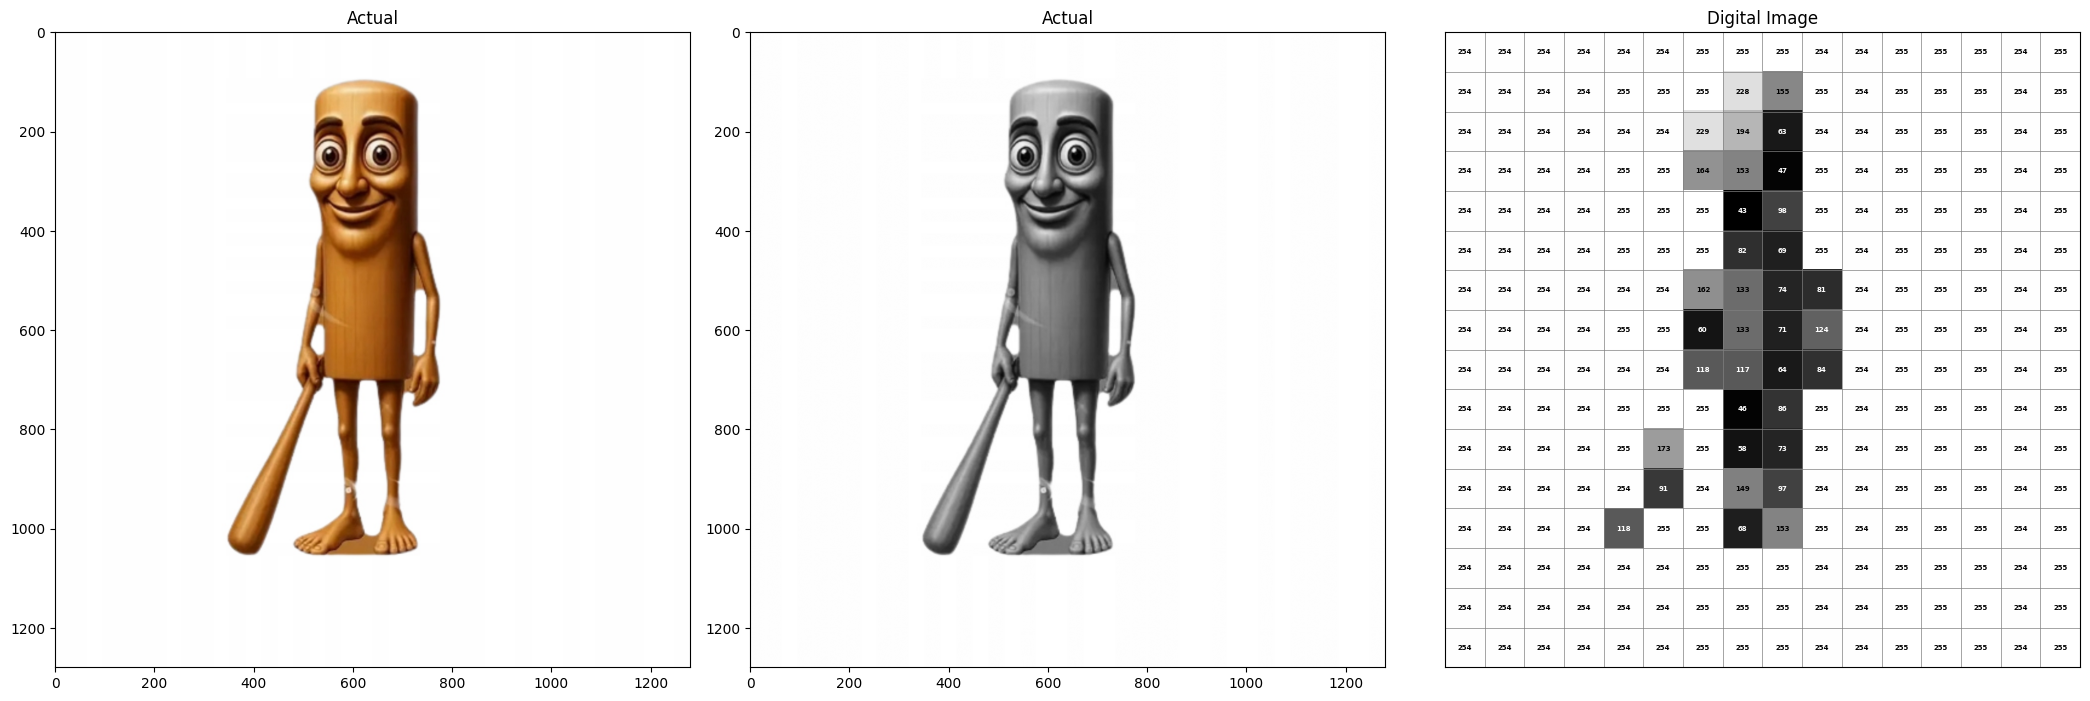

In [10]:
img_og = cv2.imread("TTTS.jpg")
img = cv2.cvtColor(img_og, cv2.COLOR_BGR2GRAY)

w, h = (16, 16)
temp = cv2.resize(img, (w, h), interpolation=cv2.INTER_LINEAR)
output = cv2.resize(temp, (w, h), interpolation=cv2.INTER_NEAREST)

fig, axes = plt.subplots(1, 3, figsize=(21, 7))

axes[0].set_title('Actual')
axes[0].imshow(cv2.cvtColor(img_og, cv2.COLOR_RGB2BGR))

axes[1].set_title('Actual')
axes[1].imshow(img, cmap='gray')


axes[2].set_title('Digital Image')
axes[2].imshow(output, cmap='gray')

for y in range(h):
    for x in range(w):
        val = output[y, x]
        text_color = 'white' if val < 128 else 'black'
        axes[2].text(x, y, str(val), ha='center', va='center', fontsize=5, color=text_color, fontweight='bold')

axes[2].set_xticks(np.arange(-0.5, w, 1), minor=True)
axes[2].set_yticks(np.arange(-0.5, h, 1), minor=True)
axes[2].grid(which='minor', color='gray', linewidth=0.5)
axes[2].tick_params(which='both', bottom=False, left=False, labelbottom=False, labelleft=False)

plt.tight_layout()
plt.show()

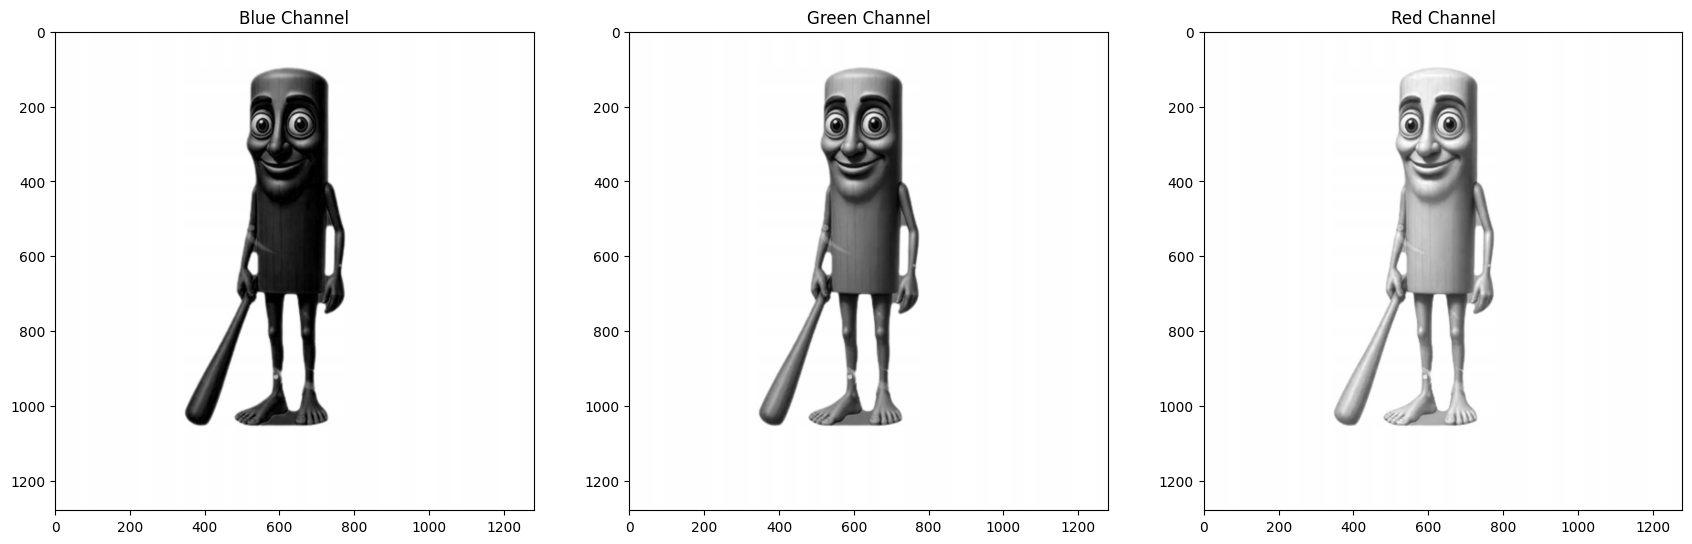

In [28]:
import cv2

img = cv2.imread('TTTS.jpg')

blueChannel = img[:, :, 0]
greenChannel = img[:, :, 1]
redChannel = img[:, :, 2]

fig, axes = plt.subplots(1, 3, figsize=(21, 7))

axes[0].set_title('Blue Channel')
axes[0].imshow(cv2.cvtColor(blueChannel, cv2.COLOR_BGR2RGB))
axes[1].set_title('Green Channel')
axes[1].imshow(cv2.cvtColor(greenChannel, cv2.COLOR_BGR2RGB))
axes[2].set_title('Red Channel')
axes[2].imshow(cv2.cvtColor(redChannel, cv2.COLOR_BGR2RGB))

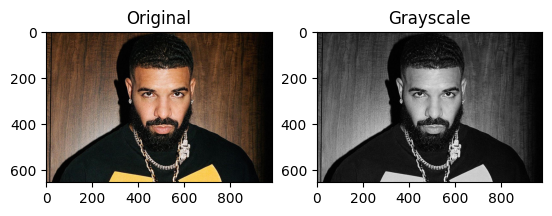

In [99]:
imgog = cv2.imread("drake.jpg")

plt.subplot(1,2,1)
plt.title('Original')
plt.imshow(cv2.cvtColor(imgog, cv2.COLOR_BGR2RGB))

plt.subplot(1,2,2)
plt.title('Grayscale')
img_gs = cv2.cvtColor(imgog, cv2.COLOR_BGR2GRAY)
plt.imshow(img_gs, cmap='gray')
plt.show()

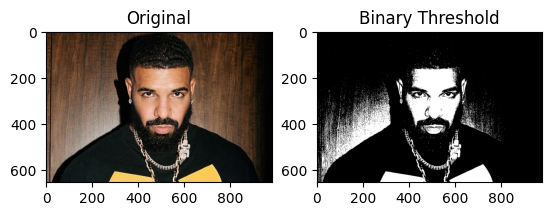

In [100]:
imgog = cv2.imread("drake.jpg")

plt.subplot(1,2,1)
plt.title('Original')
plt.imshow(cv2.cvtColor(imgog, cv2.COLOR_BGR2RGB))

plt.subplot(1,2,2)
plt.title('Binary Threshold')
img_gs = cv2.cvtColor(imgog, cv2.COLOR_BGR2GRAY)
_, img_gs = cv2.threshold(img_gs, 127,255,cv2.THRESH_BINARY)
plt.imshow(img_gs, cmap='gray')
plt.show()

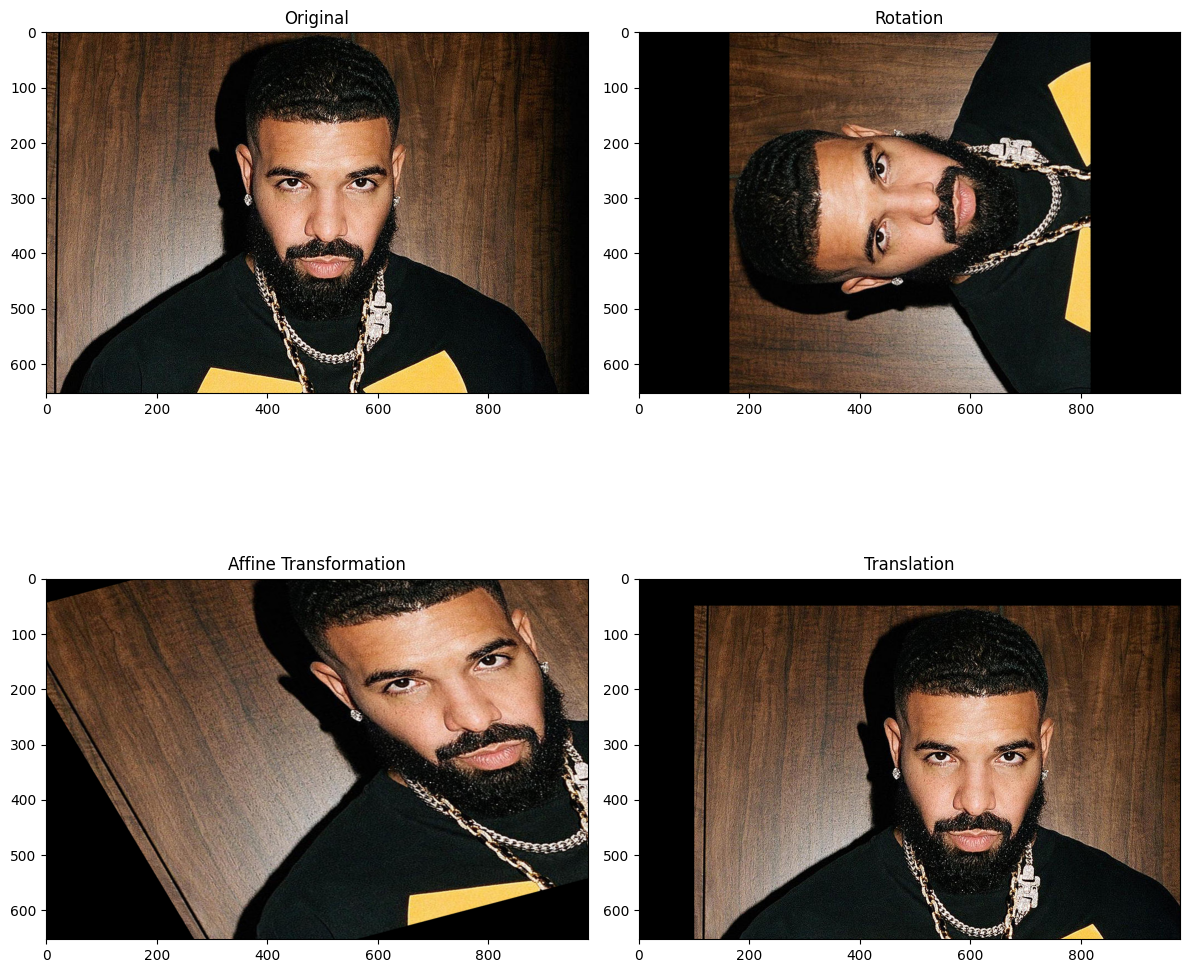

In [101]:
img = cv2.imread("drake.jpg")

fig, ax = plt.subplots(2, 2, figsize=(12, 12)) 
ax[0,0].plot(2,2,1)
ax[0,0].set_title('Original')
ax[0,0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

ax[0,1].set_title('Rotation')
rows, cols, _ = img.shape
M = cv2.getRotationMatrix2D(((cols-1)/2.0,(rows-1)/2.0),90,1)
dst = cv2.warpAffine(img,M,(cols,rows))
ax[0,1].imshow(cv2.cvtColor(dst, cv2.COLOR_BGR2RGB))

ax[1,0].set_title('Affine Transformation')
rows,cols,ch = img.shape
pts1 = np.float32([[50,50],[200,50],[50,200]])
pts2 = np.float32([[10,100],[200,50],[100,250]])
M = cv2.getAffineTransform(pts1,pts2)
dst = cv2.warpAffine(img,M,(cols,rows))
ax[1,0].imshow(cv2.cvtColor(dst, cv2.COLOR_BGR2RGB))

ax[1,1].set_title('Translation')
rows,cols,ch = img.shape
M = np.float32([[1,0,100],[0,1,50]])
dst = cv2.warpAffine(img,M,(cols,rows))
ax[1,1].imshow(cv2.cvtColor(dst, cv2.COLOR_BGR2RGB))

fig.tight_layout()
plt.show()

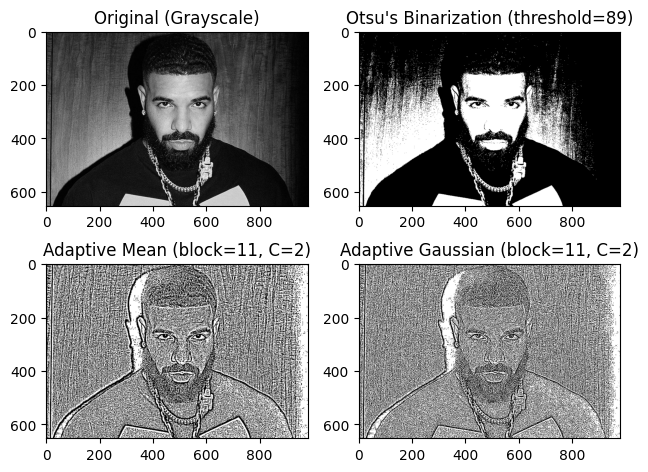

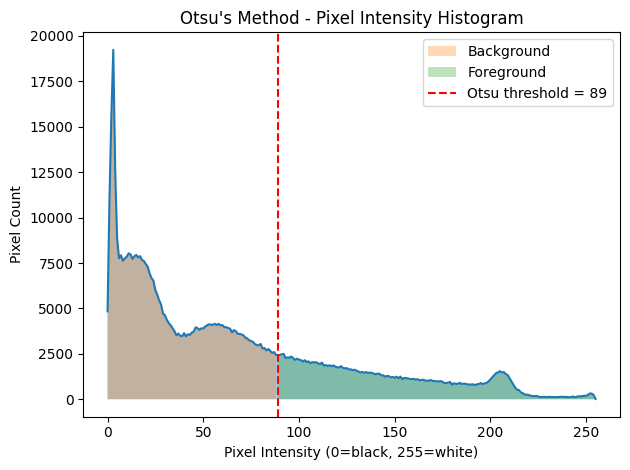

In [ ]:
imgog = cv2.imread("drake.jpg")
img_gs = cv2.cvtColor(imgog, cv2.COLOR_BGR2GRAY)

otsu_val, otsu_thresh = cv2.threshold(img_gs, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
adapt_mean = cv2.adaptiveThreshold(img_gs, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 2)
adapt_gauss = cv2.adaptiveThreshold(img_gs, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)

plt.subplot(2, 2, 1)
plt.title('Original (Grayscale)')
plt.imshow(img_gs, cmap='gray')

plt.subplot(2, 2, 2)
plt.title(f"Otsu's Binarization (threshold={int(otsu_val)})")
plt.imshow(otsu_thresh, cmap='gray')

plt.subplot(2, 2, 3)
plt.title('Adaptive Mean (block=11, C=2)')
plt.imshow(adapt_mean, cmap='gray')

plt.subplot(2, 2, 4)
plt.title('Adaptive Gaussian (block=11, C=2)')
plt.imshow(adapt_gauss, cmap='gray')

plt.tight_layout()

plt.figure()
hist = cv2.calcHist([img_gs], [0], None, [256], [0, 256]).flatten()
xs = np.arange(256)

plt.fill_between(xs, hist, alpha=0.4)
plt.plot(xs, hist)
plt.fill_between(xs[:int(otsu_val)], hist[:int(otsu_val)], alpha=0.3, label='Background')
plt.fill_between(xs[int(otsu_val):], hist[int(otsu_val):], alpha=0.3, label='Foreground')
plt.axvline(otsu_val, color='red', linestyle='--', label=f'Otsu threshold = {int(otsu_val)}')
plt.title("Otsu's Method - Pixel Intensity Histogram")
plt.xlabel('Pixel Intensity (0=black, 255=white)')
plt.ylabel('Pixel Count')
plt.legend()

plt.tight_layout()
plt.show()

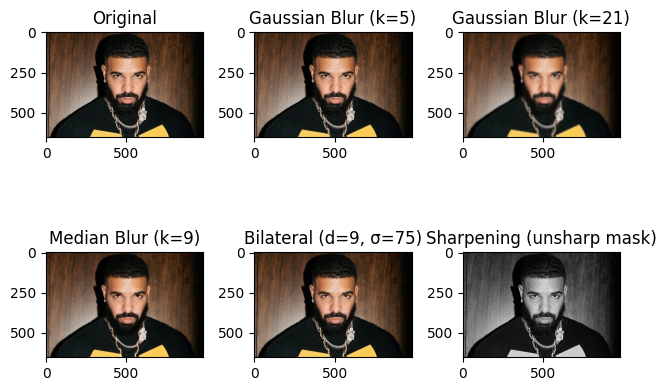

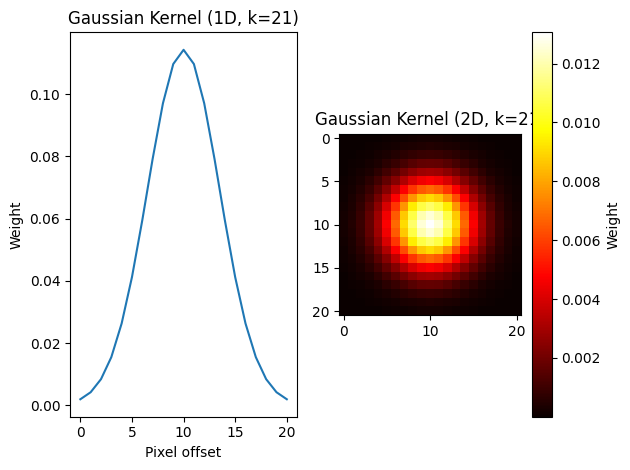

In [103]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imgog = cv2.imread("drake.jpg")
img_rgb = cv2.cvtColor(imgog, cv2.COLOR_BGR2RGB)
img_gs = cv2.cvtColor(imgog, cv2.COLOR_BGR2GRAY)

gauss_mild  = cv2.GaussianBlur(img_rgb, (5, 5), 0)
gauss_heavy = cv2.GaussianBlur(img_rgb, (21, 21), 0)
median = cv2.medianBlur(img_rgb, 9)
bilateral = cv2.bilateralFilter(img_rgb, d=9, sigmaColor=75, sigmaSpace=75)
blurred = cv2.GaussianBlur(img_gs, (9, 9), 0)
sharpened = cv2.addWeighted(img_gs, 1.5, blurred, -0.5, 0)

plt.subplot(2, 3, 1)
plt.title('Original')
plt.imshow(img_rgb)

plt.subplot(2, 3, 2)
plt.title('Gaussian Blur (k=5)')
plt.imshow(gauss_mild)

plt.subplot(2, 3, 3)
plt.title('Gaussian Blur (k=21)')
plt.imshow(gauss_heavy)

plt.subplot(2, 3, 4)
plt.title('Median Blur (k=9)')
plt.imshow(median)

plt.subplot(2, 3, 5)
plt.title('Bilateral (d=9, σ=75)')
plt.imshow(bilateral)

plt.subplot(2, 3, 6)
plt.title('Sharpening (unsharp mask)')
plt.imshow(sharpened, cmap='gray')

plt.tight_layout()

plt.figure()
kernel = cv2.getGaussianKernel(21, 0)
kernel_2d = kernel @ kernel.T

plt.subplot(1, 2, 1)
plt.title('Gaussian Kernel (1D, k=21)')
plt.plot(kernel)
plt.xlabel('Pixel offset')
plt.ylabel('Weight')

plt.subplot(1, 2, 2)
plt.title('Gaussian Kernel (2D, k=21)')
plt.imshow(kernel_2d, cmap='hot')
plt.colorbar(label='Weight')

plt.tight_layout()
plt.show()

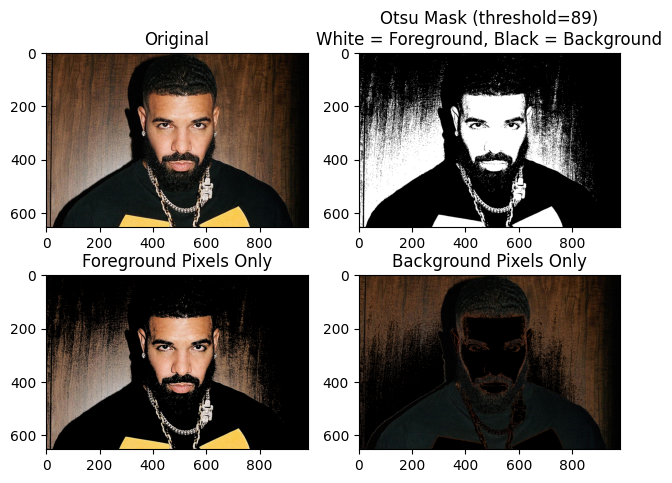

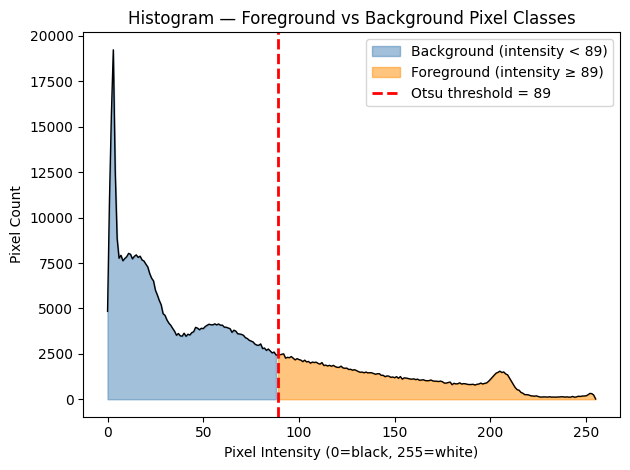

In [104]:
imgog = cv2.imread("drake.jpg")
img_gs = cv2.cvtColor(imgog, cv2.COLOR_BGR2GRAY)
img_rgb = cv2.cvtColor(imgog, cv2.COLOR_BGR2RGB)

otsu_val, otsu_thresh = cv2.threshold(img_gs, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

foreground_mask = otsu_thresh == 255
background_mask = otsu_thresh == 0

foreground_img = img_rgb.copy()
foreground_img[background_mask] = [0, 0, 0]

background_img = img_rgb.copy()
background_img[foreground_mask] = [0, 0, 0]

plt.subplot(2, 2, 1)
plt.title('Original')
plt.imshow(img_rgb)

plt.subplot(2, 2, 2)
plt.title(f"Otsu Mask (threshold={int(otsu_val)})\nWhite = Foreground, Black = Background")
plt.imshow(otsu_thresh, cmap='gray')

plt.subplot(2, 2, 3)
plt.title('Foreground Pixels Only')
plt.imshow(foreground_img)

plt.subplot(2, 2, 4)
plt.title('Background Pixels Only')
plt.imshow(background_img)

plt.tight_layout()

hist = cv2.calcHist([img_gs], [0], None, [256], [0, 256]).flatten()
xs = np.arange(256)

plt.figure()
plt.fill_between(xs[:int(otsu_val)], hist[:int(otsu_val)], alpha=0.5, color='steelblue', label=f'Background (intensity < {int(otsu_val)})')
plt.fill_between(xs[int(otsu_val):], hist[int(otsu_val):], alpha=0.5, color='darkorange', label=f'Foreground (intensity ≥ {int(otsu_val)})')
plt.plot(xs, hist, color='white' if False else 'black', linewidth=1)
plt.axvline(otsu_val, color='red', linestyle='--', linewidth=2, label=f'Otsu threshold = {int(otsu_val)}')
plt.title("Histogram — Foreground vs Background Pixel Classes")
plt.xlabel('Pixel Intensity (0=black, 255=white)')
plt.ylabel('Pixel Count')
plt.legend()

plt.tight_layout()
plt.show()

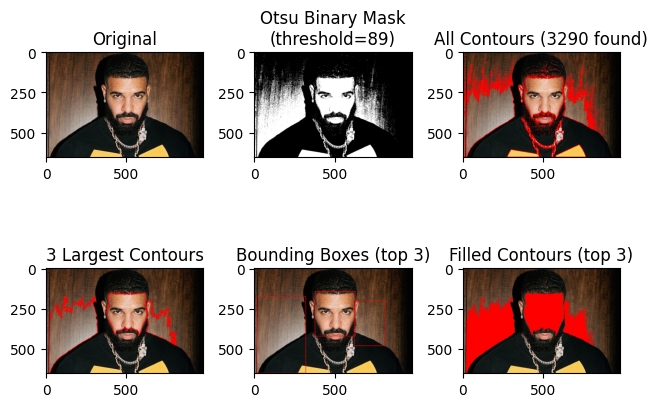

Total contours found: 3290
  Contour 1: area=76406px, perimeter=4743px
  Contour 2: area=50552px, perimeter=2161px
  Contour 3: area=21742px, perimeter=3735px


In [ ]:
imgog = cv2.imread("drake.jpg")
img_rgb = cv2.cvtColor(imgog, cv2.COLOR_BGR2RGB)
img_gs = cv2.cvtColor(imgog, cv2.COLOR_BGR2GRAY)

otsu_val, otsu_thresh = cv2.threshold(img_gs, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
contours, hierarchy = cv2.findContours(otsu_thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

contours = sorted(contours, key=cv2.contourArea, reverse=True)
all_contours = img_rgb.copy()
cv2.drawContours(all_contours, contours, -1, (255, 0, 0), 2)

top3_contours = img_rgb.copy()
cv2.drawContours(top3_contours, contours[:3], -1, (255, 0, 0), 2)

bounding_boxes = img_rgb.copy()
for cnt in contours[:3]:
    x, y, w, h = cv2.boundingRect(cnt)
    cv2.rectangle(bounding_boxes, (x, y), (x+w, y+h), (255, 0, 0), 2)

filled = img_rgb.copy()
cv2.drawContours(filled, contours[:3], -1, (255, 0, 0), thickness=cv2.FILLED)

plt.subplot(2, 3, 1)
plt.title('Original')
plt.imshow(img_rgb)

plt.subplot(2, 3, 2)
plt.title(f'Otsu Binary Mask\n(threshold={int(otsu_val)})')
plt.imshow(otsu_thresh, cmap='gray')

plt.subplot(2, 3, 3)
plt.title(f'All Contours ({len(contours)} found)')
plt.imshow(all_contours)

plt.subplot(2, 3, 4)
plt.title('3 Largest Contours')
plt.imshow(top3_contours)

plt.subplot(2, 3, 5)
plt.title('Bounding Boxes (top 3)')
plt.imshow(bounding_boxes)

plt.subplot(2, 3, 6)
plt.title('Filled Contours (top 3)')
plt.imshow(filled)

plt.tight_layout()
plt.show()